# Step 1 — Load and Inspect

What to look for:
- How many rows and columns?
- What are the column names?
- What dtype is each column?

In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/dataset.csv')
print(df.shape)
print(df.dtypes)
print(df.head())

(114000, 21)
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstree

# Step 2 — Understand the Audio Features

These are the core Spotify audio features you will use. Read each description carefully:

| Feature              | Range                   | What It Means                                                                                  |
| -------------------- | ----------------------- | ---------------------------------------------------------------------------------------------- |
| **valence**          | 0.0–1.0                 | Musical positiveness. High = happy/euphoric, Low = sad/angry                                   |
| **energy**           | 0.0–1.0                 | Intensity and activity. High = fast/loud, Low = calm/quiet                                     |
| **danceability**     | 0.0–1.0                 | How suitable for dancing based on tempo, rhythm stability, and beat strength                   |
| **acousticness**     | 0.0–1.0                 | Confidence that the track is acoustic rather than electronic                                   |
| **instrumentalness** | 0.0–1.0                 | Predicts whether a track contains no vocals. Values > 0.5 indicate a likely instrumental track |
| **liveness**         | 0.0–1.0                 | Probability that the track is a live recording                                                 |
| **speechiness**      | 0.0–1.0                 | Presence of spoken words. Values > 0.66 suggest podcast- or speech-like content                |
| **loudness**         | dB (typically –60 to 0) | Overall loudness of the track in decibels                                                      |
| **tempo**            | BPM                     | Estimated tempo in beats per minute                                                            |
| **duration_ms**      | Milliseconds            | Length of the track                                                                            |
| **key**              | 0–11                    | Musical key (0 = C, 1 = C♯/D♭, 2 = D, ..., 11 = B)                                             |
| **mode**             | 0 or 1                  | Musical modality: Major (1) or Minor (0)                                                       |
| **time_signature**   | 3–7                     | Estimated time signature (beats per measure)                                                   |


# Step 3 — Check for Missing Values

What to do:
- Columns with <1% missing: drop those rows
- Columns with >10% missing: decide if the column is worth keeping
- Never impute audio features — a song with missing valence should be dropped, not guessed

In [4]:
print(df.isnull().sum())
print(df.isnull().sum() / len(df) * 100) # As percentages

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64
Unnamed: 0          0.000000
track_id            0.000000
artists             0.000877
album_name          0.000877
track_name          0.000877
popularity          0.000000
duration_ms         0.000000
explicit            0.000000
danceability        0.000000
energy              0.000000
key                 0.000000
loudness            0.000000
mode                0.000000
speechiness         0.000000
acousticness        0.000000
instrumentalness    0.000000
liveness            0.000000
valence             0.000000
tem

Decision: "artists", "album_name" and "track_name" each has 1 row missing, so we are going to drop those independently.

In [5]:
df = df.dropna(subset=['artists', 'album_name', 'track_name'])

# Step 4 — Check Duplicates

Drop duplicates by track_id — that is the canonical identifier.

In [6]:
# Duplicate track IDs
print(df['track_id'].duplicated().sum())

# Duplicate name + artist combos
print(df.duplicated(subset=['track_name', 'artists']).sum()) # Specifies which columns to consider when identifying duplicate rows (e.g. Remasters)

df = df.drop_duplicates(subset=['track_id'])

24259
32656


# Step 5 — Distribution Analysis

These insights will affect your normalization strategy in Phase 2. Plot histograms for every audio feature:

What to look for:
- Is `instrumentalness` heavily skewed toward 0? (It will be — most songs have vocals)
- Is `speechiness` also skewed? (Yes — very few tracks are pure speech)
- Is `loudness` normally distributed or skewed? (Heavily skewed)
- Does `tempo` have a bimodal distribution? (Often yes — slow vs. fast music)

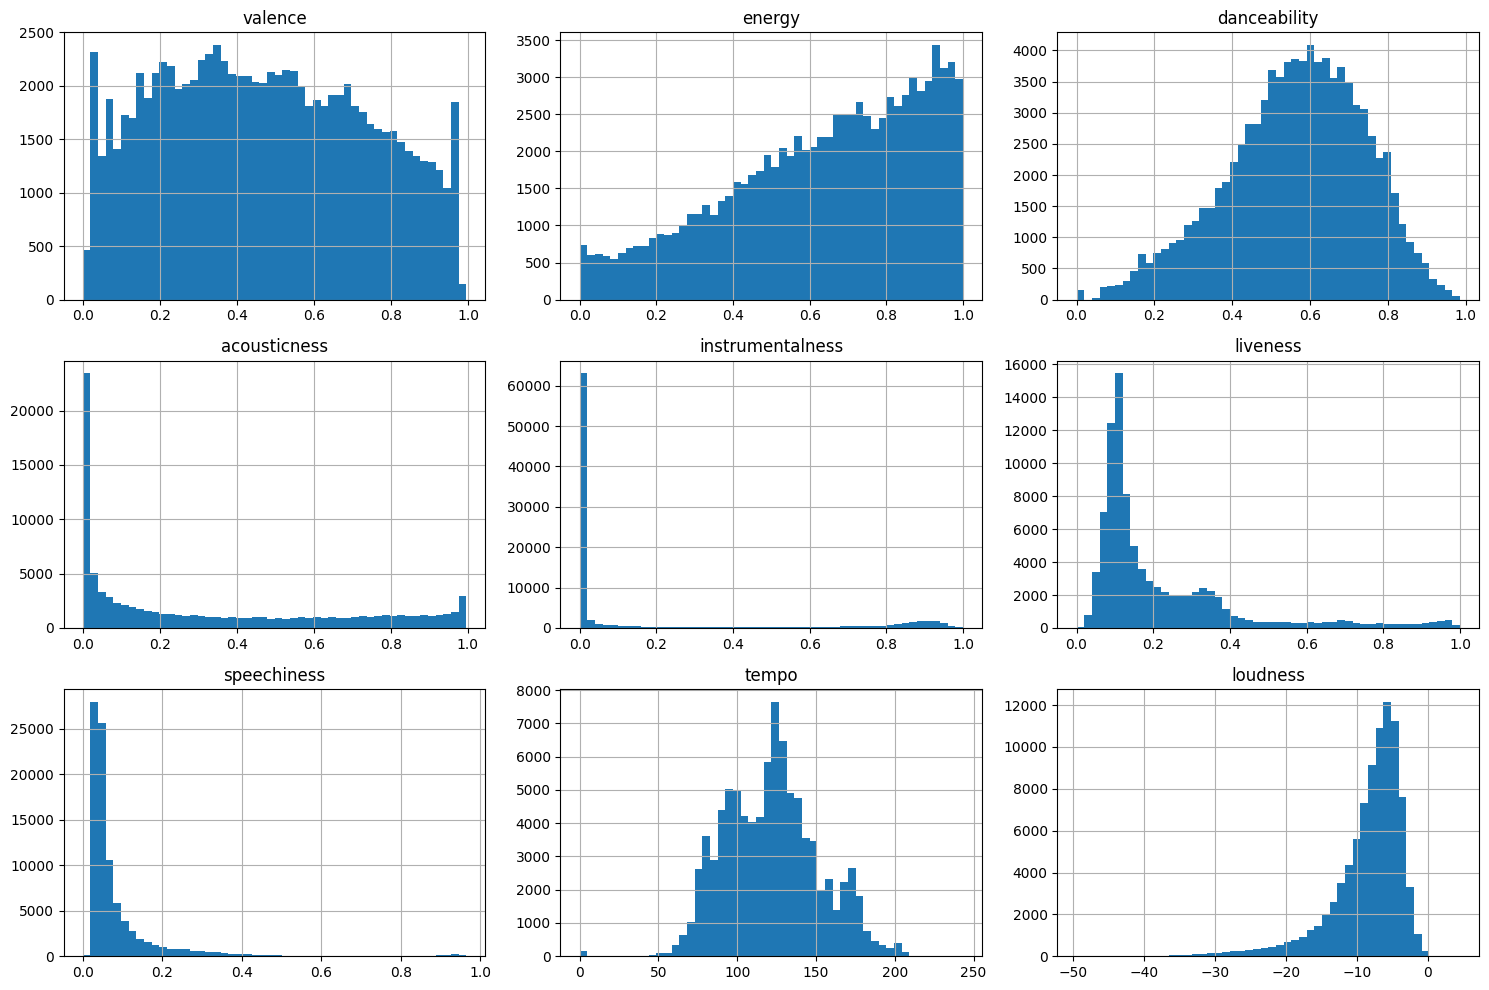

In [7]:
import matplotlib.pyplot as plt
audio_features =[
    'valence', 'energy', 'danceability', 'acousticness',
    'instrumentalness', 'liveness', 'speechiness', 'tempo', 'loudness'
]

df[audio_features].hist(bins=50, figsize=(15,10)) # Creates histogram into 50 buckets (detailed shapes) at 15 inch wide, 10 inch tall
plt.tight_layout() # Automatically adjust spacing so nothing overlap
plt.savefig('../data/processed/feature_distributions.png')
plt.show()

# Step 6 — Correlation Matrix

What to look for:

- Are `energy` and `loudness` highly correlated? (They usually are, ~0.7+)
- Is `acousticness` negatively correlated with `energy`? (Yes, typically)
- Highly correlated features carry redundant information — note which ones for Phase 2

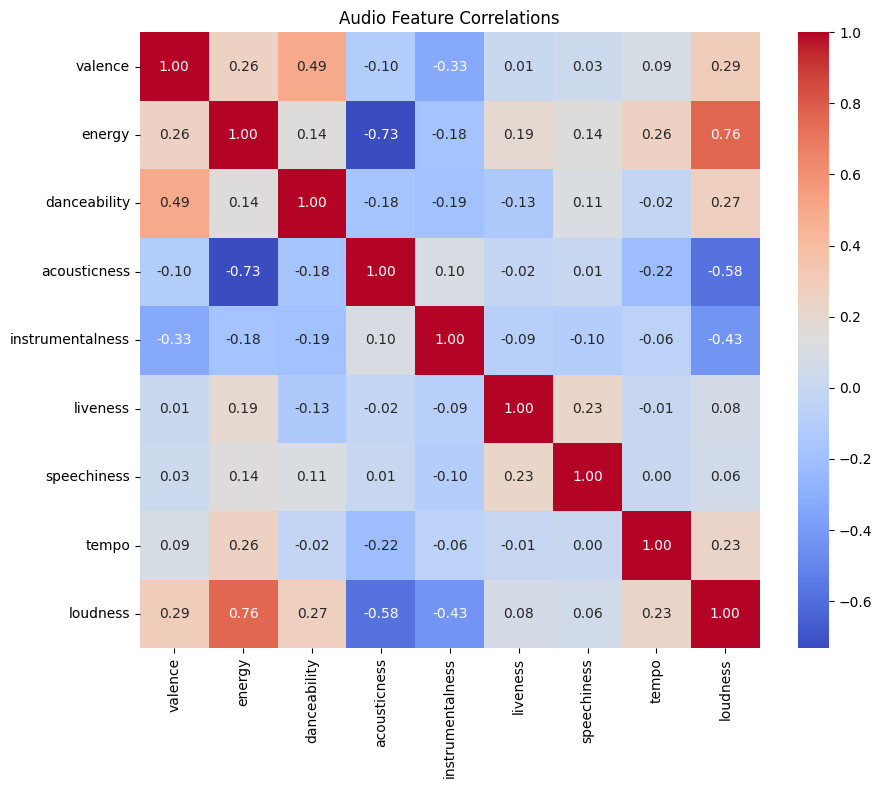

In [ ]:
import seaborn as sns

corr = df[audio_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f') # annot Adds the numeric value inside each cell, cmap chooses heatmap palette, fmt dictates annotated numbers format
plt.title('Audio Feature Correlations')
plt.savefig('../data/processed/correlation_matrix.png')
plt.show()

# Step 7 — Genre Exploration

Map genres mentally to audio feature profiles.

Example: pop tracks likely cluster high valence + high energy; ambient likely clusters low energy + high acousticness + high instrumentalness.

In [ ]:
print(df['track_genre'].value_counts().head(30)) # Display the first 30 genres
print(f"Total unique genres: {df['track_genre'].nunique()}") # Gives the number of total genres

track_genre
acoustic         1000
afrobeat          999
alt-rock          999
ambient           999
cantopop          999
tango             999
bluegrass         998
chicago-house     998
disney            998
forro             998
study             998
breakbeat         997
heavy-metal       997
sleep             997
black-metal       996
anime             995
happy             995
j-idol            995
club              994
comedy            990
idm               990
iranian           988
malay             988
salsa             988
kids              986
grindcore         985
honky-tonk        981
children          974
new-age           974
chill             972
Name: count, dtype: int64
Total unique genres: 113


# Step 8 — Save the Cleaned Dataset

In [10]:
# Drop rows with any null in key feature columns

key_cols = audio_features + ['track_name', 'artists', 'track_genre', 'track_id']
df_clean = df.dropna(subset=key_cols) # Remove rows with missing values based on columns defined in key_cols
df_clean = df_clean.drop_duplicates(subset=['track_id']) # Remove any rows with duplicated "track_id"
df_clean = df_clean.reset_index(drop=True) # After the cleanups, reset the indices (e.g. 0, 1, 5, 8 are now 0, 1, 2, 3), drop=True discards the old index entirely

df_clean.to_csv('../data/processed/tracks_clean.csv', index=False) # With index=False, will not get the extra default index
print(f"Clean dataset: {len(df_clean)} tracks")

Clean dataset: 89740 tracks
